# Notebook 03 — Validación de residuales y ajuste con t-Student si rechaza normalidad

En esta etapa se evalúan las propiedades estadísticas de los residuales obtenidos del modelo de Alaton. El objetivo es verificar si el componente estocástico cumple supuestos de:
- media cercana a cero,
- ausencia de autocorrelación,
- y normalidad.

La validación es importante porque muchos modelos climáticos asumen errores Gaussianos. Sin embargo, en datos reales es común encontrar:
- colas pesadas,
- asimetrías,
- y eventos extremos.

En caso de rechazar normalidad, se considera una distribución t-Student para representar mejor la probabilidad de eventos extremos climáticos.

In [1]:
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# =========================================================
# IMPORTAR LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# LEER DATOS
# =========================================================

df = pd.read_excel('../data/simulated_climate_rice_2000_2025.xlsx')

# =========================================================
# PREPARAR VARIABLES
# =========================================================

# Convertir fecha
df['Date'] = pd.to_datetime(df['Date'])

# Crear índice temporal
df['t'] = range(len(df))

# Calcular temperatura promedio usando Tmax y Tmin
df['T_avg'] = (
    df['Temperature_Max_C']
    + df['Temperature_Min_C']
) / 2

# =========================================================
# COMPONENTE ESTACIONAL
# =========================================================

# Crear componente seno
df['sin'] = np.sin(2 * np.pi * df['t'] / 365)

# Crear componente coseno
df['cos'] = np.cos(2 * np.pi * df['t'] / 365)

# =========================================================
# AJUSTE MODELO ALATON
# =========================================================

# Variable dependiente
y = df['T_avg']

# Variables explicativas
X = df[['t', 'sin', 'cos']]

# Agregar intercepto
X = sm.add_constant(X)

# Ajustar OLS
model = sm.OLS(y, X).fit()

# =========================================================
# OBTENER RESIDUALES
# =========================================================

# Temperatura ajustada
df['seasonal_fit'] = model.predict(X)

# Residuales
df['residuals'] = (
    df['T_avg']
    - df['seasonal_fit']
)

# =========================================================
# DATAFRAME FINAL PARA VALIDACIÓN
# =========================================================

temp = df.copy()

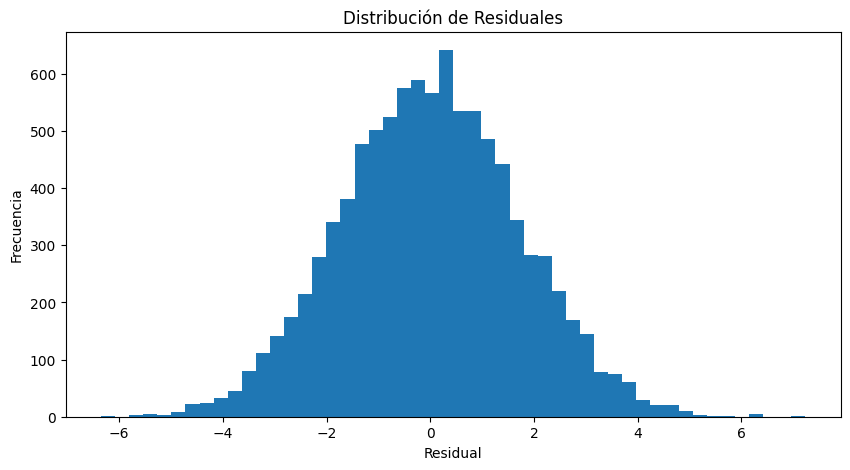

In [3]:
# =========================================================
# HISTOGRAMA DE RESIDUALES
# =========================================================

plt.figure(figsize=(10,5))

plt.hist(
    temp['residuals'],
    bins=50
)

plt.xlabel('Residual')
plt.ylabel('Frecuencia')

plt.title('Distribución de Residuales')

plt.show()

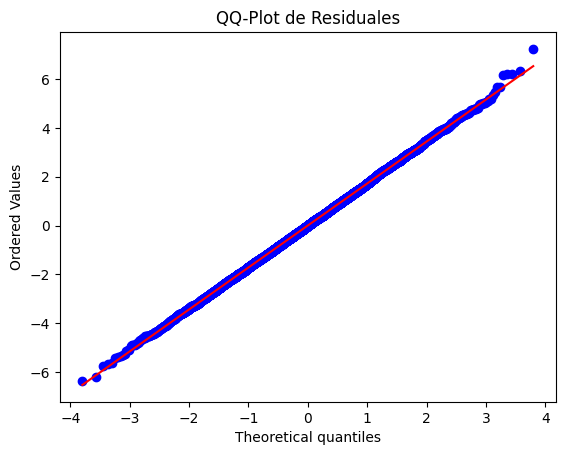

In [4]:
# =========================================================
# QQ-PLOT PARA NORMALIDAD
# =========================================================

stats.probplot(
    temp['residuals'],
    dist="norm",
    plot=plt
)

plt.title('QQ-Plot de Residuales')

plt.show()

In [13]:
# =========================================================
# TEST DE JARQUE-BERA
# =========================================================

jb_stat, jb_pvalue = stats.jarque_bera(
    temp['residuals']
)
# Imprimir resultados y comentar sobre normalidad
print("Jarque-Bera Statistic:", jb_stat)
print("p-value:", jb_pvalue)

# Interpretación del test Jarque-Bera
if jb_pvalue > 0.05:
    print("No se rechaza la hipótesis de normalidad.")
else:
    print("Se rechaza la hipótesis de normalidad.")

Jarque-Bera Statistic: 1.8001721989605053
p-value: 0.40653465581114057
No se rechaza la hipótesis de normalidad.


In [14]:
# =========================================================
# TEST DE SHAPIRO-WILK
# =========================================================
# Se toma una muestra porque Shapiro no funciona
# bien con datasets demasiado grandes

sample_res = temp['residuals'].sample(
    5000,
    random_state=42
)

shapiro_stat, shapiro_pvalue = stats.shapiro(
    sample_res
)

# Imprimir resultados y comentar sobre normalidad
print("Shapiro Statistic:", shapiro_stat)
print("p-value:", shapiro_pvalue)

# Interpretación del test Shapiro-Wilk
if shapiro_pvalue > 0.05:
    print("No se rechaza la hipótesis de normalidad.")
else:
    print("Se rechaza la hipótesis de normalidad.")

Shapiro Statistic: 0.9996586820849047
p-value: 0.581253491339397
No se rechaza la hipótesis de normalidad.


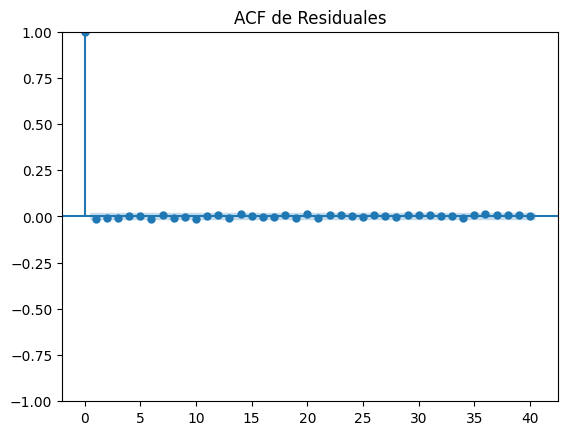

In [7]:
# =========================================================
# AUTOCORRELACIÓN DE RESIDUALES
# =========================================================

plot_acf(
    temp['residuals'],
    lags=40
)

plt.title('ACF de Residuales')

plt.show()

In [8]:
# =========================================================
# AJUSTE t-STUDENT
# =========================================================
# Se estima una distribución t-Student para capturar
# posibles colas pesadas en los residuales.

t_params = stats.t.fit(
    temp['residuals']
)

df_t, loc_t, scale_t = t_params

print("Degrees of freedom:", df_t)
print("Location:", loc_t)
print("Scale:", scale_t)

Degrees of freedom: 18415109522.459198
Location: -1.919935223263129e-07
Scale: 1.7188116779463107


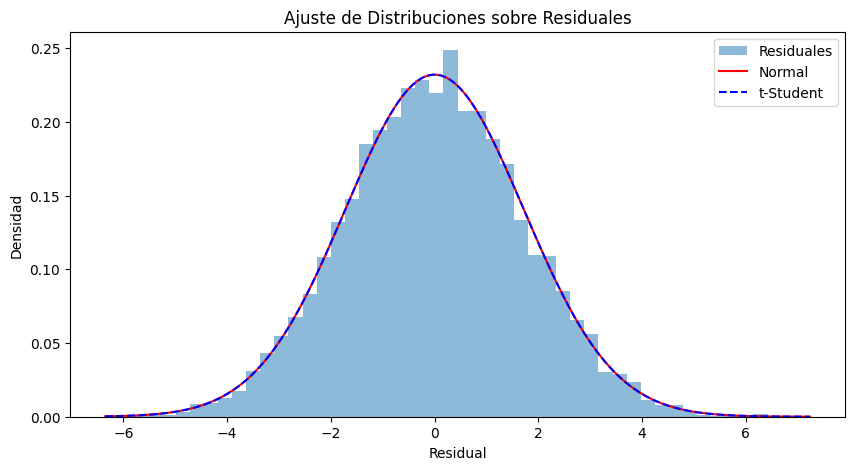

In [17]:
# =========================================================
# COMPARACIÓN NORMAL vs t-STUDENT
# =========================================================

x = np.linspace(
    temp['residuals'].min(),
    temp['residuals'].max(),
    500
)

normal_pdf = stats.norm.pdf(
    x,
    loc=temp['residuals'].mean(),
    scale=temp['residuals'].std()
)

t_pdf = stats.t.pdf(
    x,
    df=df_t,
    loc=loc_t,
    scale=scale_t
)

plt.figure(figsize=(10,5))

# Histograma
plt.hist(
    temp['residuals'],
    bins=50,
    density=True,
    alpha=0.5,
    label='Residuales'
)

# Normal con linea roja para destacar diferencias
plt.plot(
    x,
    normal_pdf,
    label='Normal',
    color='red'
)

# t-Student entrecortado para destacar diferencias en azul
plt.plot(
    x,
    t_pdf,
    label='t-Student',
    linestyle='--',
    color='blue'
)

plt.title('Ajuste de Distribuciones sobre Residuales')

plt.xlabel('Residual')
plt.ylabel('Densidad')

plt.legend()

plt.show()